# Merchant Performance & Forecasting

**Author:** Blessed Tapiwa Dongo

This notebook walks through the analysis behind Project 02: performance monitoring,
churn early-warning and revenue forecasting for a merchant-acquiring portfolio — the kind
of work I led at IMB Financial Services, recreated end-to-end.

**Data:** fully simulated — generated by [`../data/generate_data.py`](../data/generate_data.py)
(seeded, reproducible): ~185 merchants across five sectors, 30 months of monthly processing
metrics (Jan 2024 – Jun 2026). No real company data is used.

**The business questions:**

> *Which merchants are trending toward problems before the numbers say so — and how
> confident can we be in next half's revenue forecast?*

**Metric definitions:**

- **Decline rate** — declined authorisations ÷ attempted transactions.
- **Fee revenue** — the acquirer's blended fee on processed value (the number the
  business actually lives on).
- **ATV** — average transaction value.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import warnings
warnings.filterwarnings("ignore")

# --- chart chrome (validated palette — same tokens as Project 01) ---
SURFACE   = "#fcfcfb"
INK       = "#0b0b0b"
INK_2     = "#52514e"
MUTED     = "#898781"
GRID      = "#e1e0d9"
BASELINE  = "#c3c2b7"
BLUE      = "#2a78d6"
AQUA      = "#1baf7a"
RED       = "#e34948"
BLUE_LIGHT = "#9ec5f4"
BLUE_DARK  = "#1c5cab"

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "axes.edgecolor": BASELINE, "axes.labelcolor": INK_2,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False, "axes.spines.left": False,
    "font.family": "sans-serif", "font.size": 11,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlecolor": INK,
    "figure.dpi": 110, "savefig.dpi": 150, "savefig.bbox": "tight",
})

mm  = pd.read_csv("../data/sample/monthly_metrics.csv")
mer = pd.read_csv("../data/sample/merchants.csv")
df = mm.merge(mer, on="merchant_id")
df["decline_rate"] = df.declined_count / (df.txn_count + df.declined_count)
df["m"] = pd.PeriodIndex(df.month, freq="M")
df = df.sort_values(["merchant_id", "m"])

print(f"merchants:       {len(mer):,}  ({(mer.status == 'Churned').sum()} churned in window)")
print(f"monthly metrics: {len(df):,} merchant-months  ({df.m.min()} – {df.m.max()})")

merchants:       185  (22 churned in window)
monthly metrics: 3,471 merchant-months  (2024-01 – 2026-06)


## 1. Portfolio overview

How big is the book, how fast is it growing, and how exposed are we to a handful of
merchants?

Fee revenue, last 12m:  £1,507k   (prior 12m £995k, +52% — a book still in growth: new cohorts onboard throughout)
Merchants processing in Jun 2026: 163


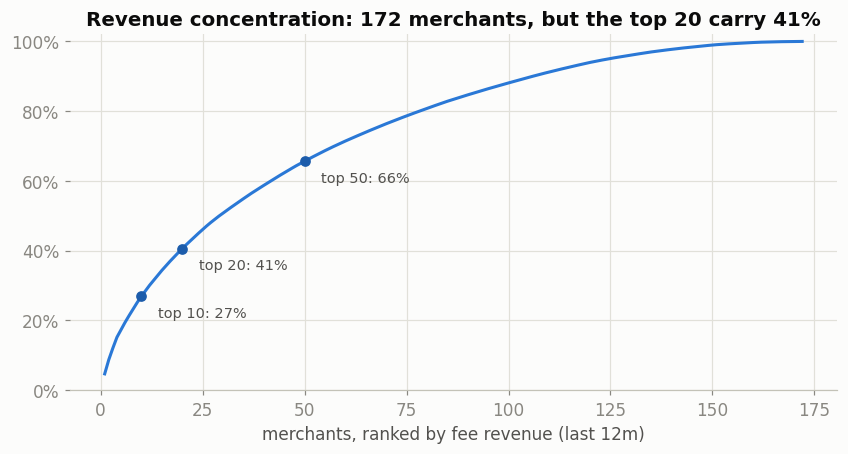

In [2]:
rev = df.groupby("m").fee_revenue_gbp.sum().sort_index()
last12, prior12 = rev[-12:].sum(), rev[-24:-12].sum()
active_now = df[df.m == df.m.max()].merchant_id.nunique()

print(f"Fee revenue, last 12m:  £{last12/1e3:,.0f}k   (prior 12m £{prior12/1e3:,.0f}k, +{(last12/prior12-1)*100:.0f}% — a book still in growth: new cohorts onboard throughout)")
print(f"Merchants processing in Jun 2026: {active_now}")

by_m = (df[df.m >= "2025-07"].groupby(["merchant_id"])
        .agg(fee=("fee_revenue_gbp", "sum")).sort_values("fee", ascending=False))
by_m["cum_pct"] = by_m.fee.cumsum() / by_m.fee.sum() * 100

fig, ax = plt.subplots(figsize=(9, 4.2))
ax.plot(range(1, len(by_m) + 1), by_m.cum_pct.values, color=BLUE, lw=2)
for n in (10, 20, 50):
    v = by_m.cum_pct.iloc[n - 1]
    ax.plot([n], [v], "o", color=BLUE_DARK, ms=6)
    ax.annotate(f"top {n}: {v:.0f}%", (n, v), xytext=(n + 4, v - 6), color=INK_2, fontsize=9.5)
ax.set_xlabel("merchants, ranked by fee revenue (last 12m)")
ax.set_title(f"Revenue concentration: {len(by_m)} merchants, but the top 20 carry {by_m.cum_pct.iloc[19]:.0f}%")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
ax.set_ylim(0, 102)
fig.savefig("../images/revenue_concentration.png")
plt.show()

**The top 20 merchants (12% of the book) carry ~41% of fee revenue.** Losing one top-20
merchant hurts more than losing a dozen from the tail — which is why the churn
early-warning problem in the next section is sized in revenue, not merchant counts.

## 2. Early warning — seeing churn before it happens

When a merchant is about to leave (insolvency, a competitor, fraud trouble), the first
place it shows is usually the **card-decline rate** — climbing weeks before volume
disappears.

**The rule:** flag a merchant when its decline rate runs **≥ 1.5× its own trailing
6-month baseline** (lagged two months, so deteriorating months don't contaminate the
baseline) for **two consecutive months**. Merchant-specific baselines matter: 4% declines
is normal for online retail and alarming for a services firm.

First, does the signature actually exist? Align every churned merchant's history on its
exit month and index decline rates to each merchant's own baseline:

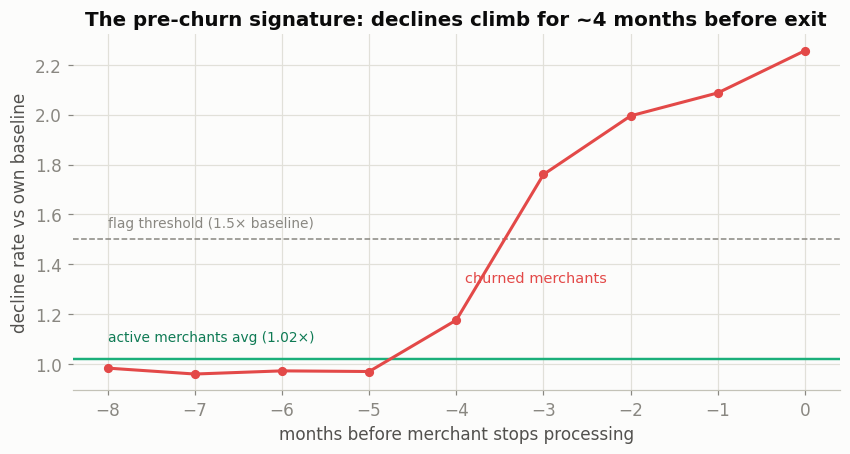

In [3]:
g = df.groupby("merchant_id")
df["baseline"] = g.decline_rate.transform(lambda s: s.shift(2).rolling(6, min_periods=4).mean())
df["ratio"] = df.decline_rate / df.baseline
df["elevated"] = (df.ratio >= 1.5) & df.baseline.notna()
df["flag"] = df.elevated & g.elevated.shift(1).fillna(False)

churned_ids = mer[mer.status == "Churned"].merchant_id
sig = []
for mid in churned_ids:
    d = df[df.merchant_id == mid].dropna(subset=["ratio"])
    last = d.m.max()
    for _, r in d.iterrows():
        sig.append({"months_before_exit": (r.m - last).n, "ratio": r.ratio})
sig = pd.DataFrame(sig)
churn_curve = sig[sig.months_before_exit >= -8].groupby("months_before_exit").ratio.mean()

active_ratio = df[(df.status == "Active") & df.ratio.notna()].ratio.mean()

fig, ax = plt.subplots(figsize=(9, 4.2))
ax.axhline(1.5, color=MUTED, lw=1, ls="--")
ax.text(-8, 1.55, "flag threshold (1.5× baseline)", color=MUTED, fontsize=9)
ax.axhline(active_ratio, color=AQUA, lw=1.6)
ax.text(-8, active_ratio + 0.07, f"active merchants avg ({active_ratio:.2f}×)", color="#0e7a54", fontsize=9)
ax.plot(churn_curve.index, churn_curve.values, color=RED, lw=2, marker="o", ms=5)
ax.text(-3.9, churn_curve.loc[-4] + 0.15, "churned merchants", color=RED, fontsize=9.5)
ax.set_xlabel("months before merchant stops processing")
ax.set_ylabel("decline rate vs own baseline")
ax.set_title("The pre-churn signature: declines climb for ~4 months before exit")
ax.set_xticks(range(-8, 1))
fig.savefig("../images/decline_signature.png")
plt.show()

The signature is real: churned merchants' decline rates start diverging from baseline
about four months out and average more than 2× baseline in the final months, while active
merchants sit flat at ~1×. Now validate the flag rule against the 22 churns in the window:

In [4]:
leads, caught = [], 0
for mid in churned_ids:
    d = df[df.merchant_id == mid]
    fl = d[d.flag]
    if len(fl):
        caught += 1
        leads.append((d.m.max() - fl.m.min()).n)

flag_now = df[(df.m == df.m.max()) & (df.status == "Active") & df.flag]
healthy = df[(df.status == "Active") & ~df.merchant_id.isin(flag_now.merchant_id)]

print(f"Churns caught before exit:   {caught}/{len(churned_ids)}")
print(f"Median warning lead time:    {np.median(leads):.0f} months before processing stops")
print(f"False alarms:                {healthy.flag.mean()*100:.1f}% of healthy merchant-months")
print()
print(f"Active merchants flagged in {df.m.max()}:")
out = flag_now.assign(annualised_fee_gbp=(flag_now.fee_revenue_gbp * 12).round(0),
                      current_vs_baseline=flag_now.ratio.round(1))
print(out[["merchant_id", "merchant_name", "sector", "current_vs_baseline",
           "annualised_fee_gbp"]].sort_values("annualised_fee_gbp", ascending=False)
      .to_string(index=False))
print(f"\nAnnualised fee revenue at risk: £{flag_now.fee_revenue_gbp.sum()*12/1e3:,.0f}k")

Churns caught before exit:   21/22
Median warning lead time:    2 months before processing stops
False alarms:                0.6% of healthy merchant-months

Active merchants flagged in 2026-06:
merchant_id       merchant_name   sector  current_vs_baseline  annualised_fee_gbp
     M-0092      Falconer Tours   Travel                  2.4             11438.0
     M-0122      Oakhurst Tours   Travel                  2.0              8895.0
     M-0045 Norbury Marketplace   Online                  1.5              4175.0
     M-0113  Cedarfield Studios Services                  1.6              2920.0

Annualised fee revenue at risk: £27k


**The rule catches 21 of 22 churns, at a median of 2 months before the merchant stops
processing, while bothering only 0.6% of healthy merchant-months.** Two months is enough
for a retention call, a pricing review, or — if the merchant is failing — an orderly exposure
wind-down. Run weekly, this list *is* the account team's priority queue.

## 3. Cohort ramp — how fast do new merchants reach full volume?

Forecasting a growing book means knowing the shape of a new merchant's ramp. Volume is
indexed to each merchant's own mature average (months 12+):

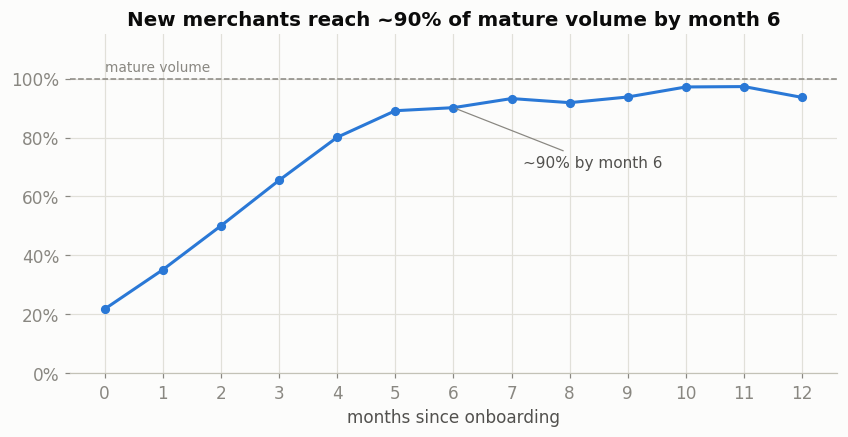

In [5]:
dfa = df[df.status == "Active"].copy()
onb = pd.PeriodIndex(dfa.onboarded_month, freq="M")
dfa["months_live"] = [(m - o).n for m, o in zip(dfa.m, onb)]

steady = (dfa[dfa.months_live >= 12].groupby("merchant_id")
          .agg(steady=("txn_value_gbp", "mean"), n=("txn_value_gbp", "size")))
steady = steady[steady.n >= 3]

ramp = dfa.merge(steady, on="merchant_id")
ramp = ramp[ramp.months_live.between(0, 12)]
curve = ramp.groupby("months_live").apply(lambda d: (d.txn_value_gbp / d.steady).mean()) * 100

fig, ax = plt.subplots(figsize=(9, 4))
ax.axhline(100, color=MUTED, lw=1, ls="--")
ax.text(0, 102.5, "mature volume", color=MUTED, fontsize=9)
ax.plot(curve.index, curve.values, color=BLUE, lw=2, marker="o", ms=5)
month90 = int(curve[curve >= 90].index.min())
ax.set_title(f"New merchants reach ~90% of mature volume by month {month90}")
ax.annotate(f"~90% by month {month90}", (month90, curve.loc[month90]),
            xytext=(month90 + 1.2, 70), color=INK_2, fontsize=10,
            arrowprops=dict(arrowstyle="-", color=MUTED, lw=0.8))
ax.set_xlabel("months since onboarding")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
ax.set_xticks(range(0, 13))
ax.set_ylim(0, 115)
fig.savefig("../images/cohort_ramp.png")
plt.show()

A new merchant lands at ~22% of its eventual volume and reaches ~90% by month five
or six. Two
practical uses: revenue from a signed pipeline can be phased realistically, and a merchant
still below ~50% of expected volume at month four is itself an early flag worth a call.

## 4. Forecasting fee revenue

Monthly portfolio fee revenue carries trend (cohort growth) and strong seasonality
(retail/online Q4, travel summer). Holt-Winters exponential smoothing (additive trend,
multiplicative seasonality) fits that structure and stays explainable to stakeholders.

**Backtest first, forecast second** — train on Jan 2024 – Dec 2025, test on the six months
we already know:

Backtest MAPE (Jan–Jun 2026): 3.1%


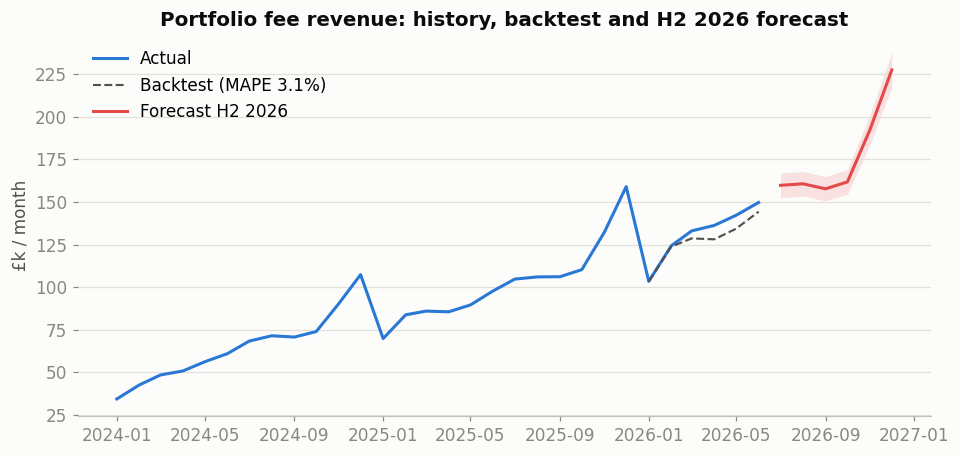

H2 2026 fee revenue forecast: £1,060k  (95% interval ±£48k)
2026-07-01    159.8
2026-08-01    160.6
2026-09-01    157.7
2026-10-01    161.8
2026-11-01    192.4
2026-12-01    227.5
Freq: MS


In [6]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

y = rev.copy()
y.index = y.index.to_timestamp()

train, test = y[:"2025-12"], y["2026-01":]
bt = ExponentialSmoothing(train, trend="add", seasonal="mul", seasonal_periods=12).fit()
bt_pred = bt.forecast(6)
mape = (abs(bt_pred.values - test.values) / test.values).mean() * 100
resid_sd = np.std((bt_pred.values - test.values) / test.values)
print(f"Backtest MAPE (Jan–Jun 2026): {mape:.1f}%")

full = ExponentialSmoothing(y, trend="add", seasonal="mul", seasonal_periods=12).fit()
fc = full.forecast(6)
lo, hi = fc * (1 - 1.96 * resid_sd), fc * (1 + 1.96 * resid_sd)

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(y.index, y.values / 1e3, color=BLUE, lw=2, label="Actual")
ax.plot(bt_pred.index, bt_pred.values / 1e3, color=INK_2, lw=1.4, ls="--", label=f"Backtest (MAPE {mape:.1f}%)")
ax.plot(fc.index, fc.values / 1e3, color=RED, lw=2, label="Forecast H2 2026")
ax.fill_between(fc.index, lo / 1e3, hi / 1e3, color=RED, alpha=0.15, linewidth=0)
ax.set_title("Portfolio fee revenue: history, backtest and H2 2026 forecast")
ax.set_ylabel("£k / month")
ax.legend(frameon=False, loc="upper left")
ax.grid(axis="x", visible=False)
fig.savefig("../images/fee_revenue_forecast.png")
plt.show()

print(f"H2 2026 fee revenue forecast: £{fc.sum()/1e3:,.0f}k  (95% interval ±£{1.96*resid_sd*fc.sum()/1e3:,.0f}k)")
print((fc / 1e3).round(1).rename("£k").to_string())

## Conclusions — what this means for the business

1. **£1.51m of fee revenue last 12 months, +51% YoY** — a book still in ramp, which is
   exactly when forecasting and churn control matter most.
2. **The churn early-warning rule works: 21 of 22 churns caught, median 2 months ahead,
   0.6% false-alarm rate.** Four active merchants are flagged today, ~£27k of annualised
   fee revenue at risk — a concrete weekly worklist for the account team.
3. **Concentration is real: top 20 merchants = ~41% of revenue.** The flagged list should
   always be cross-checked against the top-20 — a single top-tier flag outweighs the
   whole tail.
4. **New merchants ramp to ~90% of mature volume by month 5–6** — use this curve to phase
   pipeline revenue instead of assuming day-one run-rate.
5. **H2 2026 fee revenue forecast: ~£1.06m ± £48k (95%)**, on a model that backtests at
   3.1% MAPE over the last six known months. The Q4 seasonal peak (~£229k in December)
   is the number to resource for.